# Augmented Channel Charting

## Imports

In [1]:
from dataset_RT import training_set
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-02-09 13:06:19.724989: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770642379.747852    7813 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770642379.754820    7813 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770642379.772622    7813 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770642379.772640    7813 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770642379.772642    7813 computation_placer.cc:177] computation placer alr

## Feature Engineering

In [2]:
# Compute beamspace features for each CSI sample
def beamspace_features(pad_rows, pad_cols):
    def beamspace_features_func(csi, pos):
        
        with tf.device('/GPU:0'):
            csi_zeropadded = tf.pad(tf.einsum("brcs->bscr", csi[...,:]), [[0, 0], [0, 0], [pad_cols, pad_cols], [pad_rows, pad_rows]])
            csi_zeropadded = tf.signal.ifftshift(csi_zeropadded, axes = (-2, -1))

            beam_frequency_space = tf.signal.fft2d(csi_zeropadded)
            beam_frequency_space = tf.signal.fftshift(beam_frequency_space, axes = (-2, -1))
            beam_frequency_space = tf.einsum("bscr->bcrs", beam_frequency_space)
            
            power_by_beam = tf.math.reduce_sum(tf.math.abs(beam_frequency_space)**2, axis=(-1))
            mean_delay_by_beam = tf.math.angle(tf.math.reduce_sum(beam_frequency_space[...,1:] * tf.math.conj(beam_frequency_space[...,:-1]), axis=(-1)))
            beamspace_features = tf.stack((power_by_beam, mean_delay_by_beam), axis = -1)

        return csi, pos, beamspace_features

    return beamspace_features_func


elevation_res = 16
azimuth_res = 16

real_rows = tf.shape(training_set.take(1).get_single_element()[0])[1].numpy()
real_cols = tf.shape(training_set.take(1).get_single_element()[0])[2].numpy()

real_rows_half = real_rows // 2
real_cols_half = real_cols // 2

zeropadded_rows_half = elevation_res // 2
zeropadded_cols_half = azimuth_res // 2

pad_rows = zeropadded_rows_half - real_rows_half
pad_cols = zeropadded_cols_half - real_cols_half

training_set = training_set.map(beamspace_features(pad_rows, pad_cols), num_parallel_calls = tf.data.AUTOTUNE)

2026-02-09 13:06:23.229946: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144


## Load Dataset

In [3]:
dissimilarity_matrix_geodesic_meters = np.load("results/dissimilarity_matrix_geodesic_meters.npy")
classical_estimated_positions = np.load("results/classical_positions.npy")
estimated_aoas_azimuth = np.load("results/estimated_aoas_azimuth.npy")
estimated_aoas_elevation = np.load("results/estimated_aoas_elevation.npy")
delayspreads = np.load("results/delayspreads.npy")

In [4]:
groundtruth_positions = []
csi_features = []

for csi, pos, beamspace_features in training_set.prefetch(tf.data.AUTOTUNE).batch(1000):
    csi_features.append(beamspace_features.numpy())
    groundtruth_positions.append(pos.numpy())

csi_features = np.concatenate(csi_features)
groundtruth_positions = np.concatenate(groundtruth_positions)

2026-02-09 13:06:26.167439: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Manifold Learning: Finding the Low-Dimensional Representation

In [5]:
csi_features_tensor = tf.constant(csi_features)
dissimilarity_matrix_geodesic_tensor = tf.constant(dissimilarity_matrix_geodesic_meters, dtype = tf.float32)
estimated_aoas_azimuth_tensor = tf.constant(estimated_aoas_azimuth, dtype = tf.float32)
estimated_aoas_elevation_tensor = tf.constant(estimated_aoas_elevation, dtype = tf.float32)
delayspreads_tensor = tf.constant(delayspreads, dtype = tf.float32)

In [6]:
datapoint_count = tf.shape(csi_features_tensor)[0].numpy()

random_integer_pairs_dataset = tf.data.Dataset.zip(tf.data.Dataset.random(), tf.data.Dataset.random())

@tf.function
def fill_pairs(randA, randB):
    indexA = randA % datapoint_count
    indexB = randB % datapoint_count
    input = (csi_features_tensor[indexA], csi_features_tensor[indexB])
    labels = tf.concat([[dissimilarity_matrix_geodesic_tensor[indexA, indexB]], estimated_aoas_azimuth_tensor[indexA], estimated_aoas_azimuth_tensor[indexB], estimated_aoas_elevation_tensor[indexA], estimated_aoas_elevation_tensor[indexB], delayspreads_tensor[indexA], delayspreads_tensor[indexB]], 0)
    return input, labels

random_pair_dataset = random_integer_pairs_dataset.map(fill_pairs)

### The Forward Charting Function: Defining the Neural Network

In [7]:
array_count = np.shape(csi_features)[1]
azimuth_count = np.shape(csi_features)[2]
elevation_count = np.shape(csi_features)[3]
feature_count = np.shape(csi_features)[4]

cc_embmodel_input = tf.keras.Input(shape = (array_count, azimuth_count, elevation_count, feature_count), name="input")
cc_embmodel_output = tf.keras.layers.Flatten()(cc_embmodel_input)
cc_embmodel_output = tf.keras.layers.Dense(1024, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(512, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(256, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(128, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(64, activation = "relu")(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.BatchNormalization()(cc_embmodel_output)
cc_embmodel_output = tf.keras.layers.Dense(3, activation = "linear")(cc_embmodel_output)

cc_embmodel = tf.keras.Model(inputs = cc_embmodel_input, outputs = cc_embmodel_output, name = "ForwardChartingFunction")

### Siamese Network

In [8]:
input_A = tf.keras.layers.Input(shape = (array_count, azimuth_count, elevation_count, feature_count,))
input_B = tf.keras.layers.Input(shape = (array_count, azimuth_count, elevation_count, feature_count,))

embedding_A = cc_embmodel(input_A)
embedding_B = cc_embmodel(input_B)

output = tf.keras.layers.concatenate([embedding_A, embedding_B], axis=1)
model = tf.keras.models.Model([input_A, input_B], output, name = "SiameseNeuralNetwork")

# Loss function including AoA Likelihood

In [9]:
# RX positions
array_positions = np.load("dataset/array_positions.npy")
center_position = np.load("dataset/center_position.npy")

# RX directions
array_normalvectors = center_position - array_positions
array_normalvectors = array_normalvectors / np.linalg.norm(array_normalvectors, axis=1, keepdims=True)

# find upvectors & rightvectors to span local coordinate system
# constraint: rightvector is parallel to the x-y-plane
array_upvectors = np.zeros_like(array_normalvectors)
array_rightvectors = np.zeros_like(array_normalvectors)

# z-axis unit vector
z_axis_vector = np.array([0, 0, 1])

for i in range(len(array_positions)):
    normal_vector = array_normalvectors[i]
    # The rightvector is perpendicular to the normal vector and z-axis, found by the cross product.
    rightvector = np.cross(z_axis_vector, normal_vector)
    rightvector = rightvector / np.linalg.norm(rightvector)
    # The upvector is perpendicular to the normal vector and rightvector, found by the cross product.
    upvector = np.cross(normal_vector, rightvector)
    upvector = upvector / np.linalg.norm(upvector)
    # Store the vectors
    array_rightvectors[i] = rightvector
    array_upvectors[i] = upvector


array_positions_tensor = tf.constant(array_positions, dtype = tf.float32)
array_normalvectors_tensor = tf.constant(array_normalvectors, dtype = tf.float32)
array_rightvectors_tensor = tf.constant(array_rightvectors, dtype = tf.float32)
array_upvectors_tensor = tf.constant(array_upvectors, dtype = tf.float32)

In [10]:
SPEED_OF_LIGHT = 299792458
BANDWIDTH = 50e6

In [11]:
# These are some empirically determined heuristics, may be further tweaked
def get_aoa_vonmises_kappas(delayspreads):
    return 0.0000003 / (delayspreads + 0.5e-7)

# rotation matrices for each array
rot = np.stack([-array_rightvectors, array_normalvectors, array_upvectors], axis=-1)

rot_tensor = tf.constant(rot, dtype = tf.float32)

# Classical AoA-based likelihood function
def classical_likelihood_func_vectorized(pos, aoas_az, aoas_el, rms_delay_spreads):

    aoas_az = -aoas_az
    aoas_el = -aoas_el

    # "relative" has shape (number of positions, number of arrays, 3 spatial dimensions)
    relative_pos = pos[:,tf.newaxis,:3] - array_positions_tensor

    # normalized direction vectors of relative_pos in global coordinate frame
    # shape (number of positions, number of arrays, 3 spatial dimensions)
    normalized_direction_vector_global = relative_pos / tf.norm(relative_pos, axis=2, keepdims=True)

    # unit direction vector in local coordinates of the respective arrays based on the estimated AoAs
    # shape aoas (4)
    # shape direction_vector (4,3)
    estimated_unit_direction_vector_local = tf.stack([tf.cos(aoas_el)*tf.sin(aoas_az),
                                                      tf.cos(aoas_el)*tf.cos(aoas_az),
                                                      tf.sin(aoas_el)], axis=-1)
    
    # transform vector into global coordinates
    estimated_unit_direction_vector_global = tf.einsum('bij,lbj->lbi', rot_tensor, estimated_unit_direction_vector_local)

    # dot product between the two direction vectors
    dot_products = tf.einsum('lbi,lbi->lb', normalized_direction_vector_global, estimated_unit_direction_vector_global)

    # Compute AoA likelihoods based on von Mises distribution
    kappa = get_aoa_vonmises_kappas(rms_delay_spreads)
    
    aoa_likelihoods = tf.expand_dims((kappa / (4*tf.constant(np.pi, dtype=tf.float32)*tf.math.sinh(kappa))), axis=0) * tf.math.exp( tf.expand_dims(kappa, axis=0) * dot_products )

    return tf.math.reduce_prod(aoa_likelihoods, axis = -1)


def get_combined_siamese_classical_loss(classical_weight):
    def combined_siamese_classical_loss(y_true, y_pred):
        dissimilarities = y_true[:,0]
    
        pos_A, pos_B = (y_pred[:,:3], y_pred[:,3:])
        #distances_pred = tf.math.reduce_euclidean_norm(pos_A - pos_B, axis = 1)
        distances_pred = tf.math.sqrt(tf.math.reduce_sum(tf.square(pos_A - pos_B), axis = 1))
        siamese_loss = tf.reduce_mean(tf.square(distances_pred - dissimilarities))
    
        aoa_az_A = y_true[:,1:1+array_count]
        aoa_az_B = y_true[:,1+array_count:1+2*array_count]
        aoa_el_A = y_true[:,1+2*array_count:1+3*array_count]
        aoa_el_B = y_true[:,1+3*array_count:1+4*array_count]
        ds_A = y_true[:,1+4*array_count:1+5*array_count]
        ds_B = y_true[:,1+5*array_count:1+6*array_count]
        classical_loss = -tf.reduce_sum(classical_likelihood_func_vectorized(pos_A, aoa_az_A, aoa_el_A, ds_A) + classical_likelihood_func_vectorized(pos_B, aoa_az_B, aoa_el_B, ds_B))
        
        return classical_weight * classical_loss + (1 - classical_weight) * siamese_loss

    return combined_siamese_classical_loss

### Training

In [12]:
optimizer = tf.keras.optimizers.Adam()

# Feel free to tweak these training hyperparameters - a good choice of these paremters is important for performance!
samples_per_session = 200000
learning_rates = [5e-3, 5e-4, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6, 1e-6]
batch_sizes = [400, 800, 1200, 2000, 3000, 3000, 4000, 5000]
classical_weights = [0.98, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75]


for session, learning_rate, batch_size, classical_weight in zip(range(len(learning_rates)), learning_rates, batch_sizes, classical_weights):
    print("\nTraining Session ", session + 1, "\nBatch Size: ", batch_size, "\nLearning rate: ", learning_rate)

    # Fit model
    model.compile(loss = get_combined_siamese_classical_loss(classical_weight), optimizer = optimizer)#, jit_compile=False)
    optimizer.learning_rate.assign(learning_rate)
    steps_per_epoch = int(samples_per_session / batch_size)
    model.fit(random_pair_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE), steps_per_epoch = int(samples_per_session / batch_size))

    # Quick evaluation
    channel_chart_positions = cc_embmodel.predict(csi_features_tensor)
    errorvectors = groundtruth_positions - channel_chart_positions
    print(f"Mean Absolute Error (MAE): {np.mean(np.sqrt(errorvectors[:,0]**2 + errorvectors[:,1]**2 + errorvectors[:,2]**2)):.4f}m")


Training Session  1 
Batch Size:  400 
Learning rate:  0.005


I0000 00:00:1770642390.669138    7903 service.cc:152] XLA service 0x730624021850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770642390.669180    7903 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-02-09 13:06:30.786841: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770642391.383914    7903 cuda_dnn.cc:529] Loaded cuDNN version 90300


 16/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3211

I0000 00:00:1770642394.431057    7903 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: -2.2049
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Mean Absolute Error (MAE): 1.2475m

Training Session  2 
Batch Size:  800 
Learning rate:  0.0005
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: -6.1567
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error (MAE): 1.2669m

Training Session  3 
Batch Size:  1200 
Learning rate:  0.0001
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: -9.5031
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error (MAE): 1.2542m

Training Session  4 
Batch Size:  2000 
Learning rate:  5e-05
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: -15.9083
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error (MAE): 1.2392m

Training Session  5 
Batch Size:  3000 
Learning rate:  1e-05
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: -24.0125
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error (MAE): 1.2405m

Training Session  6 
Batch Size:  3000 
Learning rate:  5e-06
66/66 ━━━━━━━━

## Optional: Evaluation, Plots

In [13]:
%matplotlib widget 

def plot_colorized(positions, groundtruth_positions, title = None, alpha = 1.0, save_path = None):
	# Generate RGB colors for datapoints
    center_point = np.zeros(3, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    center_point[2] = 0.5 * (np.min(groundtruth_positions[:, 2], axis = 0) + np.max(groundtruth_positions[:, 2], axis = 0))
    NormalizeData = lambda in_data : (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 2])

	# Plot datapoints
    ax = plt.figure(figsize=(7,6)).add_subplot(projection='3d')
    ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c = rgb_values, s = 5, alpha = alpha, linewidths = 3)

    ax.scatter(array_positions[:,0], array_positions[:,1], array_positions[:,2], marker = 's', s = 7, c = 'black', alpha = 1, linewidth = 5)
    
    ax.set_zlim(0,11)
    ax.set_xlabel('x-coordinate $[m]$')
    ax.set_ylabel('y-coordinate $[m]$')
    ax.set_zlabel('z-coordinate $[m]$')

    ax.set_box_aspect([np.ptp(groundtruth_positions[:, 0]), np.ptp(groundtruth_positions[:, 1]), 1.5*np.ptp(groundtruth_positions[:, 2])])
    
    # Customize the view angle so it's easier to see that the scatter points lie
    # on the plane y=0
    ax.view_init(elev=40., azim=125, roll=0)
    plt.tight_layout()
    plt.subplots_adjust(left=-0.05, right=0.95, top=1.0, bottom=0.05)
    if save_path is not None:
        plt.savefig(save_path, dpi=600)
    plt.show()


def plot_cdf(positions, reference_positions, title = None):
    errorvectors = reference_positions[:,:3] - positions
    errors = np.sqrt(errorvectors[:,0]**2 + errorvectors[:,1]**2 + errorvectors[:,2]**2)
    count, bins_count = np.histogram(errors, bins=200)
    pdf = count / sum(count)
    cdf = np.cumsum(pdf)
    
    bins_count[0] = 0
    cdf = np.append([0], cdf)

    plt.figure(figsize=(5, 4))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.plot(bins_count, cdf)
    plt.title("MAE = " + f"{(np.mean(errors)):.3f}m")
    plt.xlim((0, 4))
    plt.xlabel("Absolute Localization Error [m]")
    plt.ylabel("CDF")
    plt.grid()
    plt.show()

### Evaluate on Training Set (Self-supervised Learning)

In [14]:
# Compute channel chart positions for all CSI samples in the training set
channel_chart_positions = cc_embmodel.predict(csi_features_tensor)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


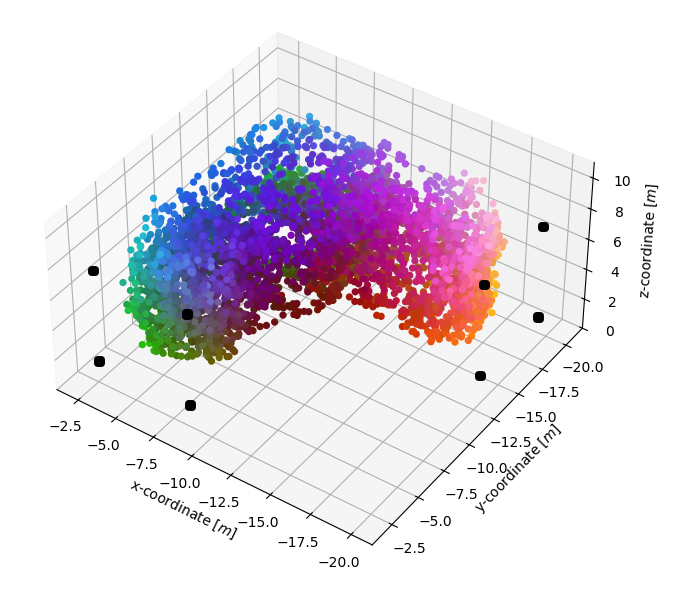

In [15]:
# Augmented channel chart positions
plot_colorized(channel_chart_positions, groundtruth_positions, save_path = "results/augmented_cc_positions.png")

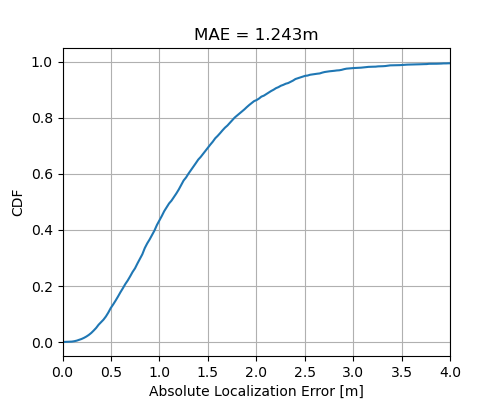

In [16]:
# CDF of localization errors
plot_cdf(channel_chart_positions, groundtruth_positions)